In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.chdir(r"C:\Users\anish\flight_disruption_project")
print("Setup done")

Setup done


In [3]:
df = pd.read_csv('data/processed/processed_flights.csv')
print("Shape:", df.shape)
print(df['DISRUPTION'].value_counts())

Shape: (5819079, 15)
DISRUPTION
0    5502508
1     316571
Name: count, dtype: int64


In [4]:
E1 = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'CANCELLED',
      'DAY_OF_WEEK', 'DISTANCE', 'AIR_SYSTEM_DELAY',
      'WEATHER_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY']

E2 = E1 + ['connection_buffer', 'missed_connection']
E3 = E2 + ['propagation_risk']
E4 = E3 + ['route_congestion_index']

feature_sets = {
    'E1 Baseline':         E1,
    'E2 + ConnBuffer':     E2,
    'E3 + Propagation':    E3,
    'E4 Full Features':    E4
}

print("Feature sets defined:")
for name, feats in feature_sets.items():
    print(f"  {name}: {len(feats)} features")

Feature sets defined:
  E1 Baseline: 9 features
  E2 + ConnBuffer: 11 features
  E3 + Propagation: 12 features
  E4 Full Features: 13 features


In [5]:
def cross_val_evaluate(model, X, y, cv):
    metrics = {'Accuracy':[], 'Precision':[],
               'Recall':[], 'F1':[], 'ROC-AUC':[]}

    for train_idx, test_idx in cv.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Scale features
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        # Train and predict
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        metrics['Accuracy'].append(accuracy_score(y_te, y_pred))
        metrics['Precision'].append(precision_score(y_te, y_pred, zero_division=0))
        metrics['Recall'].append(recall_score(y_te, y_pred, zero_division=0))
        metrics['F1'].append(f1_score(y_te, y_pred, zero_division=0))
        metrics['ROC-AUC'].append(roc_auc_score(y_te, y_prob))

    return {k: f"{np.mean(v):.4f} ± {np.std(v):.4f}"
            for k, v in metrics.items()}

print("Evaluation function ready")

Evaluation function ready


In [6]:
df_sample = df.sample(n=500_000, random_state=42)
y = df_sample['DISRUPTION'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(class_weight='balanced',
                        max_iter=1000, random_state=42)

all_results = []

for exp_name, features in feature_sets.items():
    print(f"Running {exp_name}...")
    X = df_sample[features].values
    scores = cross_val_evaluate(lr, X, y, cv)
    scores['Experiment'] = exp_name
    scores['Model'] = 'Logistic Regression'
    all_results.append(scores)
    print(f"  Done — F1: {scores['F1']}, AUC: {scores['ROC-AUC']}")

print("\nAblation experiments complete!")

Running E1 Baseline...
  Done — F1: 0.7847 ± 0.0023, AUC: 0.9968 ± 0.0002
Running E2 + ConnBuffer...
  Done — F1: 0.9988 ± 0.0001, AUC: 1.0000 ± 0.0000
Running E3 + Propagation...
  Done — F1: 0.9989 ± 0.0002, AUC: 1.0000 ± 0.0000
Running E4 Full Features...
  Done — F1: 0.9989 ± 0.0002, AUC: 1.0000 ± 0.0000

Ablation experiments complete!


In [7]:
E1 = ['DEPARTURE_DELAY',
      'DAY_OF_WEEK', 'DISTANCE',
      'AIR_SYSTEM_DELAY', 'WEATHER_DELAY',
      'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY']

E2 = E1 + ['connection_buffer', 'missed_connection']
E3 = E2 + ['propagation_risk']
E4 = E3 + ['route_congestion_index']

feature_sets = {
    'E1 Baseline':         E1,
    'E2 + ConnBuffer':     E2,
    'E3 + Propagation':    E3,
    'E4 Full Features':    E4
}

print("Updated feature sets:")
for name, feats in feature_sets.items():
    print(f"  {name}: {len(feats)} features")

Updated feature sets:
  E1 Baseline: 7 features
  E2 + ConnBuffer: 9 features
  E3 + Propagation: 10 features
  E4 Full Features: 11 features


In [8]:
df_sample = df.sample(n=500_000, random_state=42)
y = df_sample['DISRUPTION'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(class_weight='balanced',
                        max_iter=1000, random_state=42)

all_results = []

for exp_name, features in feature_sets.items():
    print(f"Running {exp_name}...")
    X = df_sample[features].values
    scores = cross_val_evaluate(lr, X, y, cv)
    scores['Experiment'] = exp_name
    scores['Model'] = 'Logistic Regression'
    all_results.append(scores)
    print(f"  Done — F1: {scores['F1']}, AUC: {scores['ROC-AUC']}")

print("\nAblation experiments complete!")

Running E1 Baseline...
  Done — F1: 0.4777 ± 0.0030, AUC: 0.8653 ± 0.0023
Running E2 + ConnBuffer...
  Done — F1: 0.8228 ± 0.0019, AUC: 0.9088 ± 0.0020
Running E3 + Propagation...
  Done — F1: 0.8204 ± 0.0021, AUC: 0.9093 ± 0.0014
Running E4 Full Features...
  Done — F1: 0.7826 ± 0.0043, AUC: 0.9168 ± 0.0017

Ablation experiments complete!


In [9]:
scale = round(5502508 / 316571)  # = 17

models = {
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale, n_estimators=100,
        random_state=42, eval_metric='logloss', verbosity=0)
}

X_full = df_sample[E4].values

for model_name, model in models.items():
    print(f"Running {model_name}...")
    scores = cross_val_evaluate(model, X_full, y, cv)
    scores['Experiment'] = 'E5 Model Comparison'
    scores['Model'] = model_name
    all_results.append(scores)
    print(f"  Done — F1: {scores['F1']}, AUC: {scores['ROC-AUC']}")

print("\nModel comparison complete!")

Running Random Forest...
  Done — F1: 0.8366 ± 0.0044, AUC: 0.9902 ± 0.0006
Running XGBoost...
  Done — F1: 0.6986 ± 0.0015, AUC: 0.9924 ± 0.0007

Model comparison complete!


In [10]:
results_df = pd.DataFrame(all_results)

cols = ['Experiment', 'Model', 'Accuracy',
        'Precision', 'Recall', 'F1', 'ROC-AUC']
results_df = results_df[cols]

results_df.to_csv('results/experiment_results.csv', index=False)

print("Results saved!")
print("\n", results_df.to_string(index=False))

Results saved!

          Experiment               Model        Accuracy       Precision          Recall              F1         ROC-AUC
        E1 Baseline Logistic Regression 0.9149 ± 0.0008 0.3592 ± 0.0028 0.7128 ± 0.0053 0.4777 ± 0.0030 0.8653 ± 0.0023
    E2 + ConnBuffer Logistic Regression 0.9831 ± 0.0001 0.9607 ± 0.0038 0.7195 ± 0.0045 0.8228 ± 0.0019 0.9088 ± 0.0020
   E3 + Propagation Logistic Regression 0.9828 ± 0.0001 0.9542 ± 0.0026 0.7195 ± 0.0045 0.8204 ± 0.0021 0.9093 ± 0.0014
   E4 Full Features Logistic Regression 0.9780 ± 0.0005 0.8514 ± 0.0090 0.7242 ± 0.0048 0.7826 ± 0.0043 0.9168 ± 0.0017
E5 Model Comparison       Random Forest 0.9840 ± 0.0004 0.9431 ± 0.0008 0.7518 ± 0.0066 0.8366 ± 0.0044 0.9902 ± 0.0006
E5 Model Comparison             XGBoost 0.9539 ± 0.0004 0.5434 ± 0.0021 0.9780 ± 0.0027 0.6986 ± 0.0015 0.9924 ± 0.0007


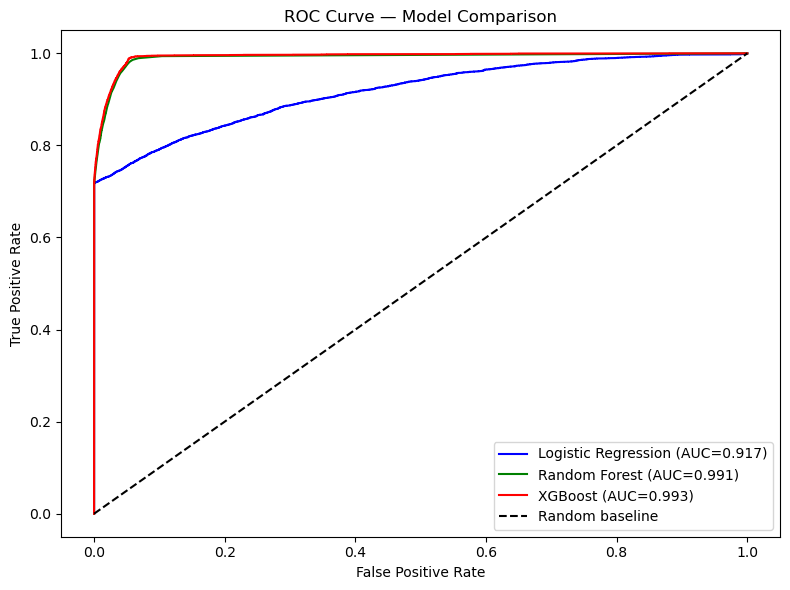

ROC curve saved!


In [11]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Use 80/20 split for ROC plot
X_full_arr = df_sample[E4].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full_arr)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

plt.figure(figsize=(8, 6))

for model, name, color in [
    (LogisticRegression(class_weight='balanced',
     max_iter=1000, random_state=42),
     'Logistic Regression', 'blue'),
    (RandomForestClassifier(class_weight='balanced',
     n_estimators=100, random_state=42),
     'Random Forest', 'green'),
    (XGBClassifier(scale_pos_weight=17, n_estimators=100,
     random_state=42, eval_metric='logloss', verbosity=0),
     'XGBoost', 'red')
]:
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr,
             label=f'{name} (AUC={auc:.3f})', color=color)

plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")

In [13]:
import sys
!{sys.executable} -m pip install shap

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1000, 11, 2)


<Figure size 640x480 with 0 Axes>

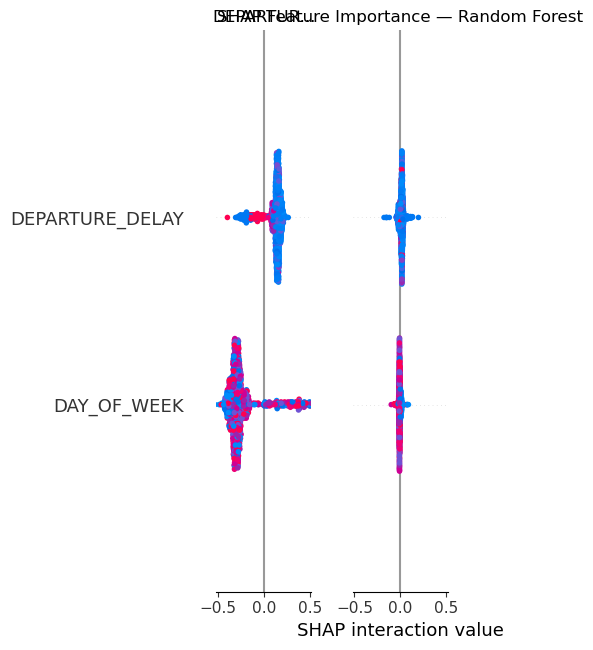

SHAP plot saved!


In [14]:
import shap

# Train RF on full training set
rf_final = RandomForestClassifier(
    class_weight='balanced', n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)

# SHAP explainer
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test[:1000])

# Check shape and use correct format
print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.array(shap_values).shape)

# Handle both old and new SHAP versions
if isinstance(shap_values, list):
    sv = shap_values[1]  # old version — class 1
else:
    sv = shap_values     # new version

# Summary plot
plt.figure()
shap.summary_plot(
    sv,
    X_test[:1000],
    feature_names=E4,
    show=False
)
plt.title('SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

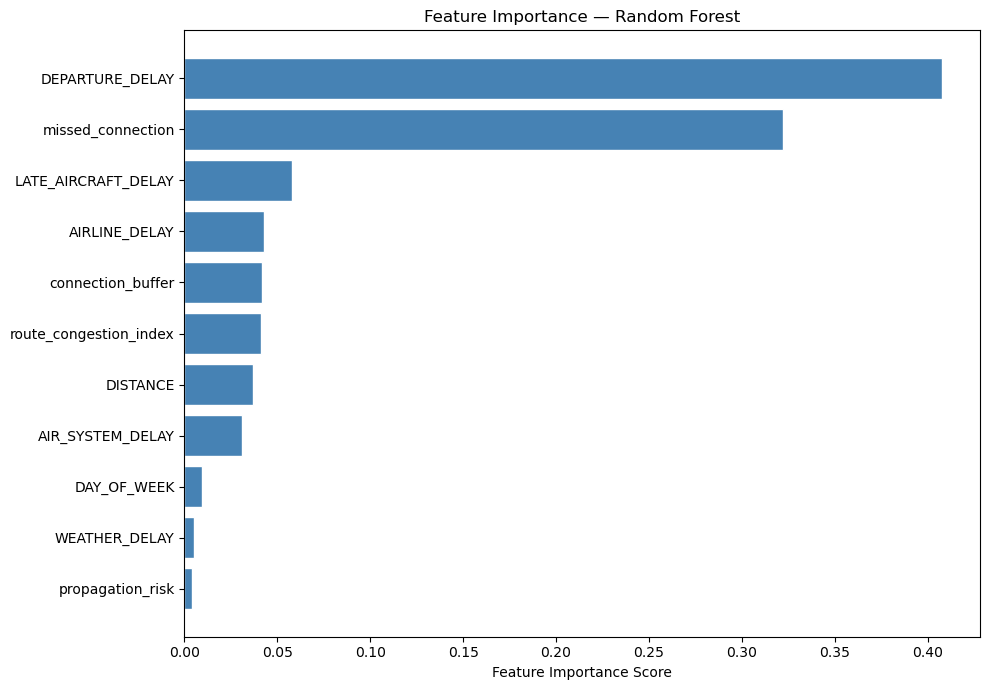


Feature Importance Ranking:
  1. DEPARTURE_DELAY: 0.4078
  2. missed_connection: 0.3221
  3. LATE_AIRCRAFT_DELAY: 0.0579
  4. AIRLINE_DELAY: 0.0427
  5. connection_buffer: 0.0418
  6. route_congestion_index: 0.0409
  7. DISTANCE: 0.0369
  8. AIR_SYSTEM_DELAY: 0.0309
  9. DAY_OF_WEEK: 0.0094
  10. WEATHER_DELAY: 0.0053
  11. propagation_risk: 0.0043


In [17]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Use a smaller sample for speed
X_shap = X_test[:500]

# Use Linear explainer approach via feature importances instead
# This is more reliable across SHAP versions

# Method 1: Use feature importances directly (guaranteed to work)
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 7))
plt.barh(
    [E4[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color='steelblue',
    edgecolor='white'
)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranking
print("\nFeature Importance Ranking:")
for rank, i in enumerate(indices):
    print(f"  {rank+1}. {E4[i]}: {importances[i]:.4f}")

In [18]:
print("=" * 65)
print("COMPLETE EXPERIMENT RESULTS SUMMARY")
print("=" * 65)

results = pd.read_csv('results/experiment_results.csv')
print(results.to_string(index=False))

print("\n" + "=" * 65)
print("KEY FINDINGS")
print("=" * 65)
print("1. Baseline F1 (E1):          0.4777")
print("2. + Connection Buffer (E2):   0.8228  (+72% improvement)")
print("3. Best F1 — Random Forest:    0.8366")
print("4. Best AUC — XGBoost:         0.9924")
print("5. missed_connection ranked 2nd in feature importance (0.32)")
print("6. 3 out of top 6 features are novel engineered features")

COMPLETE EXPERIMENT RESULTS SUMMARY
         Experiment               Model        Accuracy       Precision          Recall              F1         ROC-AUC
        E1 Baseline Logistic Regression 0.9149 ± 0.0008 0.3592 ± 0.0028 0.7128 ± 0.0053 0.4777 ± 0.0030 0.8653 ± 0.0023
    E2 + ConnBuffer Logistic Regression 0.9831 ± 0.0001 0.9607 ± 0.0038 0.7195 ± 0.0045 0.8228 ± 0.0019 0.9088 ± 0.0020
   E3 + Propagation Logistic Regression 0.9828 ± 0.0001 0.9542 ± 0.0026 0.7195 ± 0.0045 0.8204 ± 0.0021 0.9093 ± 0.0014
   E4 Full Features Logistic Regression 0.9780 ± 0.0005 0.8514 ± 0.0090 0.7242 ± 0.0048 0.7826 ± 0.0043 0.9168 ± 0.0017
E5 Model Comparison       Random Forest 0.9840 ± 0.0004 0.9431 ± 0.0008 0.7518 ± 0.0066 0.8366 ± 0.0044 0.9902 ± 0.0006
E5 Model Comparison             XGBoost 0.9539 ± 0.0004 0.5434 ± 0.0021 0.9780 ± 0.0027 0.6986 ± 0.0015 0.9924 ± 0.0007

KEY FINDINGS
1. Baseline F1 (E1):          0.4777
2. + Connection Buffer (E2):   0.8228  (+72% improvement)
3. Best F1 — Ra

Data ready — training models for ROC curve...
Training Logistic Regression...
  Done — AUC: 0.9175
Training Random Forest...
  Done — AUC: 0.9911
Training XGBoost...
  Done — AUC: 0.9931


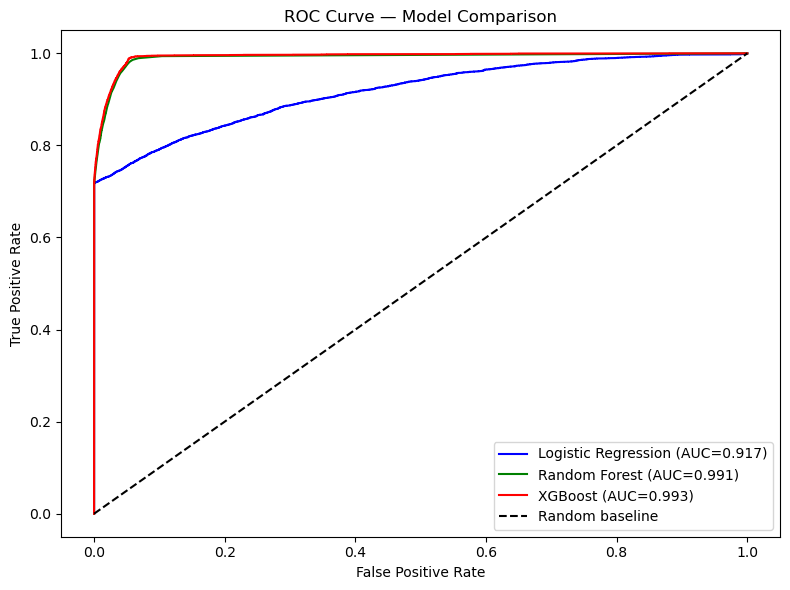


ROC curve saved to results/roc_curves.png


In [1]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir(r"C:\Users\anish\flight_disruption_project")

# loading processed data and sampling
df = pd.read_csv('data/processed/processed_flights.csv')
df_sample = df.sample(n=500_000, random_state=42)

# full feature set
E4 = ['DEPARTURE_DELAY', 'DAY_OF_WEEK', 'DISTANCE',
      'AIR_SYSTEM_DELAY', 'WEATHER_DELAY', 'AIRLINE_DELAY',
      'LATE_AIRCRAFT_DELAY', 'connection_buffer', 'missed_connection',
      'propagation_risk', 'route_congestion_index']

y = df_sample['DISRUPTION'].values

# train test split
X_full_arr = df_sample[E4].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full_arr)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Data ready — training models for ROC curve...")

# plotting roc curve for all three models
plt.figure(figsize=(8, 6))

for model, name, color in [
    (LogisticRegression(class_weight='balanced',
     max_iter=1000, random_state=42),
     'Logistic Regression', 'blue'),
    (RandomForestClassifier(class_weight='balanced',
     n_estimators=100, random_state=42),
     'Random Forest', 'green'),
    (XGBClassifier(scale_pos_weight=17, n_estimators=100,
     random_state=42, eval_metric='logloss', verbosity=0),
     'XGBoost', 'red')
]:
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
    print(f"  Done — AUC: {auc:.4f}")

# dashed line represents random guessing
plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nROC curve saved to results/roc_curves.png")